# Detection and Localization of Isolated Points in Images Using Digital Image Processing

**DIP Mini Project**



## Project Workflow

Input Image → Point Detection Mask → Filtering → Thresholding → Binary Segmentation → Contour Detection → Circle Localization → Counting → Evaluation

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Create the Input Image

We create a simple test image containing 11 isolated bright points.

Saving Screenshot 2026-09-20 171108.png to Screenshot 2026-09-20 171108 (1).png


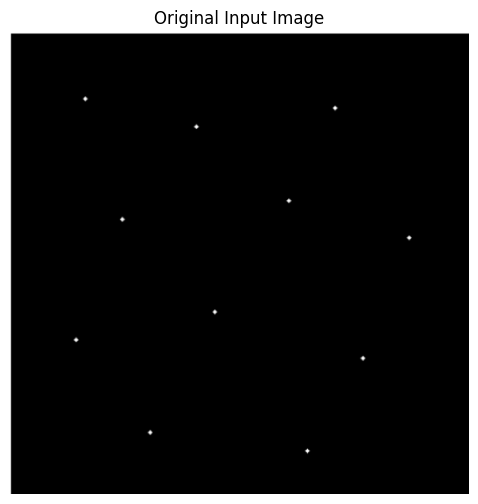

In [10]:
from google.colab import files

# Upload your image
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Read the image
image = cv2.imread(filename)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the uploaded image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Input Image")
plt.axis("off")
plt.show()

In [3]:
cv2.imwrite('isolated_points_input.png', image)
print('Saved: isolated_points_input.png')

Saved: isolated_points_input.png


## 2. Point-Detection Mask

The mask used for isolated-point detection is:

[-1 -1 -1]

[-1  8 -1]

[-1 -1 -1]

The center pixel gets a strong positive weight while its eight neighbors get negative weights.

In [4]:
point_mask = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

print(point_mask)

[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


## 3. Apply the Point-Detection Mask

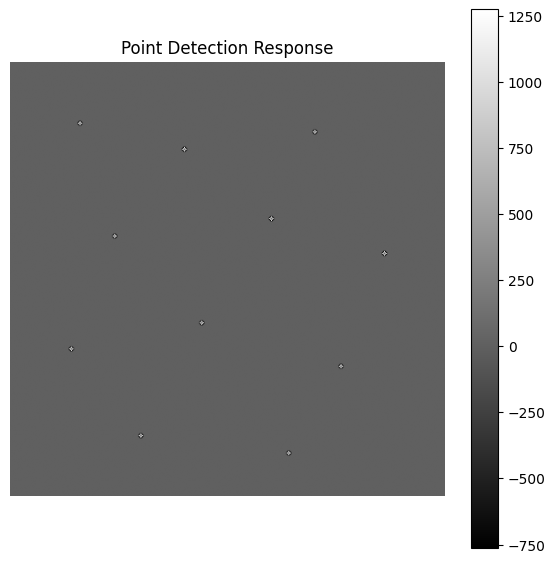

In [5]:
filtered = cv2.filter2D(image.astype(np.float32), -1, point_mask)

plt.figure(figsize=(7, 7))
plt.imshow(filtered, cmap='gray')
plt.title('Point Detection Response')
plt.colorbar()
plt.axis('off')
plt.show()

## 4. Thresholding

A threshold is used to keep strong point-detection responses and remove the background.

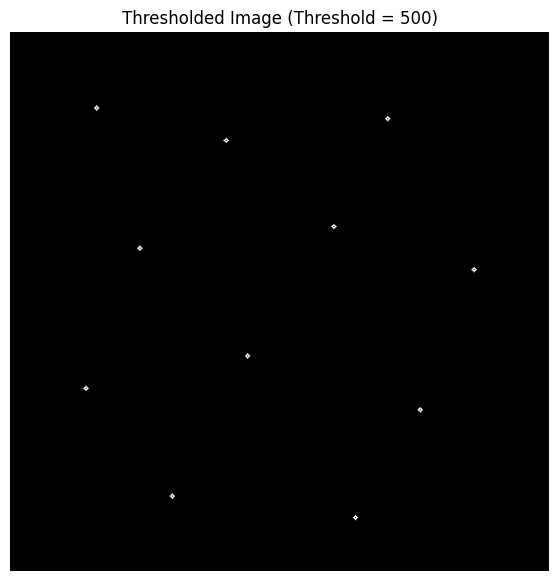

In [6]:
threshold_value = 500
binary = np.where(filtered > threshold_value, 255, 0).astype(np.uint8)

plt.figure(figsize=(7, 7))
plt.imshow(binary, cmap='gray')
plt.title(f'Thresholded Image (Threshold = {threshold_value})')
plt.axis('off')
plt.show()

## 5. Find Detected Regions

In [7]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print('Detected regions before filtering:', len(contours))

Detected regions before filtering: 11


## 6. Localize the Points and Draw Circles

In [8]:
result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
detected_centers = []

for contour in contours:
    area = cv2.contourArea(contour)

    # Ignore empty contours
    if area >= 0:
        M = cv2.moments(contour)

        if M['m00'] != 0:
            center_x = int(M['m10'] / M['m00'])
            center_y = int(M['m01'] / M['m00'])
            detected_centers.append((center_x, center_y))

# Sort for stable display/counting
detected_centers = sorted(detected_centers, key=lambda p: (p[1], p[0]))

for i, (x, y) in enumerate(detected_centers, start=1):
    cv2.circle(result, (x, y), 10, (0, 0, 255), 2)
    cv2.putText(result, str(i), (x + 12, y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

detected_count = len(detected_centers)
print('Detected isolated points:', detected_count)

Detected isolated points: 11


## 7. Final Result

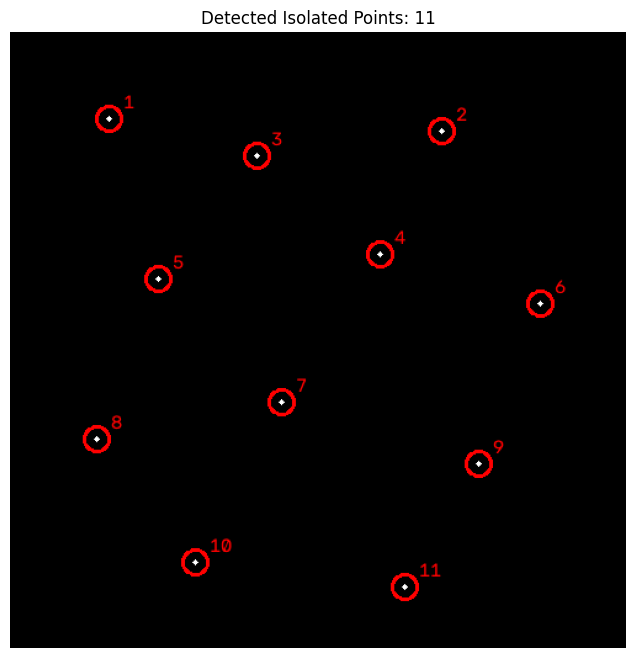

Saved: isolated_points_detected.png


In [9]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title(f'Detected Isolated Points: {detected_count}')
plt.axis('off')
plt.show()

cv2.imwrite('isolated_points_detected.png', result)
print('Saved: isolated_points_detected.png')

## 8. Before and After Comparison

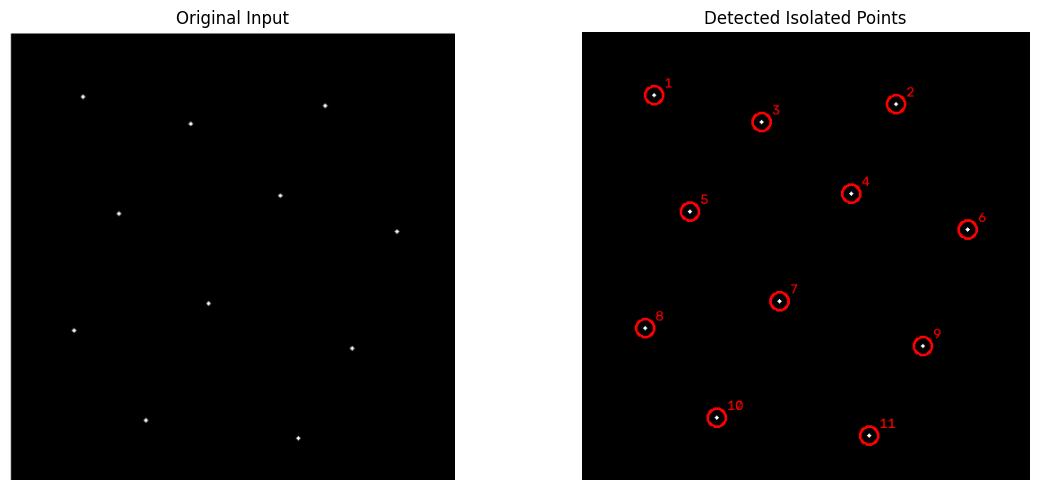

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Input')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Detected Isolated Points')
plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Evaluation

Because the test image was generated with a known number of points, we can compare the actual number with the detected number.

In [13]:
actual_points = len(points)
detected_points = detected_count

detection_accuracy = (detected_points / actual_points) * 100

print('Actual points:   ', actual_points)
print('Detected points: ', detected_points)
print(f'Detection accuracy: {detection_accuracy:.2f}%')

Actual points:    11
Detected points:  11
Detection accuracy: 100.00%


## 10. Threshold Comparison

Different threshold values can change the number of detected points. This demonstrates parameter sensitivity.

In [14]:
thresholds = [100, 300, 500, 700]
comparison = []

for t in thresholds:
    test_binary = np.where(filtered > t, 255, 0).astype(np.uint8)
    test_contours, _ = cv2.findContours(
        test_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    comparison.append((t, len(test_contours)))

print('Threshold | Detected regions')
print('----------------------------')
for t, count in comparison:
    print(f'{t:9} | {count}')

Threshold | Detected regions
----------------------------
      100 | 11
      300 | 11
      500 | 11
      700 | 11
